In [34]:
import os

from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    LeaveOneOut,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [35]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'TRAINING DATASETS' in dirs:
        print("✅ Found TRAINING DATASETS at:")
        print(os.path.join(root, 'TRAINING DATASETS'))
        break

✅ Found TRAINING DATASETS at:
/content/drive/MyDrive/TRAINING DATASETS


In [37]:
import pandas as pd

# Google Sheet URL (ensure it's published for CSV export)
gene_list_url = 'https://docs.google.com/spreadsheets/d/1K23ZNh8uKkA_bYFULjkUHaFxFJQ1rMXpfUgjPQY-09o/export?format=csv&gid=0'

try:
    # Read the CSV with header=0 to treat the first row as headers.
    # Then extract the first column's values.
    gene_df = pd.read_csv(gene_list_url, header=0)
    # Assuming the actual gene symbols are in the first column of the sheet, and the first row was a header.
    # We'll use the column name from the sheet, which was 'Gene / Marker'
    gene_list = gene_df['Gene / Marker'].astype(str).str.strip().tolist()

    print(f"Successfully loaded {len(gene_list)} genes from the Google Sheet.")
except Exception as e:
    print(f"Error loading gene list: {e}")
    gene_list = [] # Initialize as empty to prevent errors in subsequent steps

Successfully loaded 126 genes from the Google Sheet.


In [38]:
drug_sensitivity_url = 'https://docs.google.com/spreadsheets/d/1ryEtG3YvHQg_N1-OuqPWzWEM4wrya9Q9i2CP5dpOOoo/export?format=csv&gid=0'
response_score_url = 'https://docs.google.com/spreadsheets/d/1K23ZNh8uKkA_bYFULjkUHaFxFJQ1rMXpfUgjPQY-09o/export?format=csv&gid=0'

try:
    drug_sensitivity_df = pd.read_csv(drug_sensitivity_url)
    print(f"Successfully loaded drug sensitivity data with {len(drug_sensitivity_df)} rows and {len(drug_sensitivity_df.columns)} columns.")
    display(drug_sensitivity_df.head(3))
except Exception as e:
    print(f"Error loading drug sensitivity data: {e}")

try:
    response_score_df = pd.read_csv(response_score_url)
    print(f"\nSuccessfully loaded response score data with {len(response_score_df)} rows and {len(response_score_df.columns)} columns.")
    display(response_score_df.head(3))
except Exception as e:
    print(f"\nError loading response score data: {e}")

Successfully loaded drug sensitivity data with 15 rows and 8 columns.


,CELL LINE,DRUG NAME,DRUG TARGETS,IC50 (μM),LN_IC50,AUC,RMSE,Z SCORE
0,HL-60,Cytarabine,Antimetabolite,1.290,0.251494,0.863939,0.035360,-0.559
1,EoL-1-cell,Cytarabine,Antimetabolite,0.197,-1.626779,0.660582,0.033278,-1.410
2,GDM-1,Cytarabine,Antimetabolite,0.145,-1.932383,0.606282,0.058568,-1.540



Successfully loaded response score data with 126 rows and 6 columns.


,Gene / Marker,Response Association,Function,Biological Role,Evidence Category,Response Score
0,5-AZACYTIDINE,Indirectly sensitivity-enhancing,Hypomethylating agent capable of restoring SLC...,DNA methylation / drug transport,Experimental intervention,-0.5
1,5-NT,Resistance-associated,Dephosphorylates nucleotides and nucleotide an...,Nucleotide metabolism,Mechanistic,1.0
2,ACN9,Sensitivity-associated,Associated with the predictive signature; spec...,Not specified,Predictive marker,-1.0


In [39]:
pd.set_option('future.no_silent_downcasting', True)

DATA_DIR = "/content/drive/MyDrive/TRAINING DATASETS"
OUTPUT_DIR = './processed_cell_lines'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Safety check for pre-loaded dataframes
if 'drug_sensitivity_df' not in globals() or 'response_score_df' not in globals():
    raise NameError("Please run your 1st cell (data loading cell) to define 'drug_sensitivity_df' and 'response_score_df' first.")

# 1. Cell Line Selection
cell_line_col = 'CELL LINE' if 'CELL LINE' in drug_sensitivity_df.columns else 'cell_line_names'
CELL_LINES = drug_sensitivity_df[cell_line_col].dropna().unique().tolist() if cell_line_col in drug_sensitivity_df.columns else []

# 2. Score Mappings
CANCER_DRIVER_SCORES = {
    'TRUE': 1.0, 'YES': 1.0, '1': 1.0, '1.0': 1.0,
    'FALSE': 0.0, 'NO': 0.0, '0': 0.0, '0.0': 0.0
}

# Mutation effect scores are arbitrary for now but shall be changed in the next iteration of the model using data complaint with online portals like DepMap.
MUTATION_EFFECT_SCORES = {
    "nonsense": 10.0,
    "frameshift": 9.5,
    "ess_splice": 9.0,
"splice_variant": 9.0,
    "CNA": 9.0,
    "stop_lost": 8.5,
    "start_lost": 8.5,
    "SO:0000010:protein_coding,SO:0000147:exon,SO:0000316:CDS,SO:1000032:indel,SO:0001650:inframe_variant,SO:0001652:inframe_codon_loss": 6.0,
    "inframe": 6.0,
    "deletion": 6.0,
    "insertion": 6.0,
    "missense": 5.0,
    "snp": 5.0,
    "silent": 1.0,
    "undefined":0.0,
}
# 3. Clean Target Response Score Master Table
resp_gene_col = [c for c in response_score_df.columns if c.strip().lower() in ['gene / marker', 'gene', 'symbol']][0]

# Prioritize the actual numeric 'Response Score' column
resp_score_col = 'Response Score' if 'Response Score' in response_score_df.columns else \
                 [c for c in response_score_df.columns if 'score' in c.lower() and 'response' not in c.lower()][0] # Fallback to 'Score' if present

gene_df = response_score_df[[resp_gene_col, resp_score_col]].copy()
gene_df.columns = ['Gene / Marker', 'Response Score']
gene_df['JOIN_KEY'] = gene_df['Gene / Marker'].astype(str).str.strip().str.upper()
gene_df['Response Score'] = pd.to_numeric(gene_df['Response Score'], errors='coerce')
gene_df = gene_df.drop_duplicates(subset=['JOIN_KEY'])

# List to accumulate DataFrames across all cell lines
all_cell_line_dfs = []

for cell_line in CELL_LINES:
    print(f"Processing cell line: {cell_line}...")

    rna_file = os.path.join(DATA_DIR, f"CMP_{cell_line}_rnaseq.csv")
    mut_file = os.path.join(DATA_DIR, f"CMP_{cell_line}_mutations.csv")

    if not os.path.exists(rna_file) or not os.path.exists(mut_file):
        print(f"  Files missing for {cell_line}. Skipping.")
        continue

    # Load & Clean RNA Data
    df_rna = pd.read_csv(rna_file)
    df_rna.columns = df_rna.columns.str.strip()

    rna_symbol_col = [c for c in ['Symbol', 'Gene', 'gene_symbol', 'GENE_SYMBOL'] if c in df_rna.columns]
    rna_symbol_col = rna_symbol_col[0] if rna_symbol_col else df_rna.columns[0]

    df_rna['JOIN_KEY'] = df_rna[rna_symbol_col].astype(str).str.strip().str.upper()

    tpm_col = [c for c in df_rna.columns if 'tpm' in c.lower()]
    if tpm_col:
        df_rna['TPM value'] = (
            df_rna[tpm_col[0]]
            .astype(str)
            .str.replace(',', '')
            .str.strip()
        )
        df_rna['TPM value'] = pd.to_numeric(df_rna['TPM value'], errors='coerce')
        df_rna = df_rna.sort_values(by=['JOIN_KEY', 'TPM value'], ascending=[True, False])
    else:
        # Assign np.nan if TPM column is not found, to differentiate from actual 0.0 values
        df_rna['TPM value'] = np.nan

    df_rna = df_rna.drop_duplicates(subset=['JOIN_KEY'], keep='first')
    df_rna = df_rna[['JOIN_KEY', 'TPM value']]

    # Load & Clean Mutation Data
    df_mut = pd.read_csv(mut_file)
    df_mut.columns = df_mut.columns.str.strip()

    mut_symbol_col = [c for c in ['Symbol', 'Gene', 'gene_symbol', 'GENE_SYMBOL'] if c in df_mut.columns]
    mut_symbol_col = mut_symbol_col[0] if mut_symbol_col else df_mut.columns[0]

    df_mut['JOIN_KEY'] = df_mut[mut_symbol_col].astype(str).str.strip().str.upper()

    # Cancer Driver Gene
    driver_col = [c for c in df_mut.columns if 'driver' in c.lower()]
    if driver_col:
        clean_driver_str = df_mut[driver_col[0]].astype(str).str.strip().str.upper()
        df_mut['Cancer driver gene'] = clean_driver_str.isin(['TRUE', 'YES', '1', '1.0'])
        df_mut['Cancer_Driver_Score'] = clean_driver_str.map(CANCER_DRIVER_SCORES).fillna(0.0)
    else:
        df_mut['Cancer driver gene'] = False
        df_mut['Cancer_Driver_Score'] = 0.0

    # Effect
    effect_col = [c for c in df_mut.columns if 'effect' in c.lower()]
    if effect_col:
        df_mut['Effect'] = df_mut[effect_col[0]].fillna('Wild-Type').astype(str).str.strip()
        df_mut['Effect_Score'] = (
            df_mut['Effect']
            .str.lower()
            .map(MUTATION_EFFECT_SCORES)
            .fillna(0.0)
        )
    else:
        df_mut['Effect'] = 'Wild-Type'
        df_mut['Effect_Score'] = 0.0

    # VAF
    vaf_col = [c for c in df_mut.columns if 'vaf' in c.lower()]
    if vaf_col:
        df_mut['VAF'] = (
            df_mut[vaf_col[0]]
            .astype(str)
            .str.replace(',', '')
            .str.strip()
        )
        df_mut['VAF'] = pd.to_numeric(df_mut['VAF'], errors='coerce').fillna(0.0)
        df_mut = df_mut.sort_values(by=['JOIN_KEY', 'VAF'], ascending=[True, False])
    else:
        df_mut['VAF'] = 0.0

    df_mut = df_mut.drop_duplicates(subset=['JOIN_KEY'], keep='first')
    df_mut = df_mut[['JOIN_KEY', 'Cancer driver gene', 'Cancer_Driver_Score', 'Effect', 'Effect_Score', 'VAF']]

    # MERGE & SAFE DEFAULTS

    genomic_df = pd.merge(df_rna, df_mut, on='JOIN_KEY', how='outer')
    cell_df = pd.merge(genomic_df, gene_df, on='JOIN_KEY', how='inner') # Changed to inner join

    # Assign Cell Line and Symbol column
    cell_df['CELL LINE'] = cell_line
    cell_df['Symbol'] = cell_df['Gene / Marker'].fillna(cell_df['JOIN_KEY'])

    # Fill default values explicitly after joins.
    # Fill missing TPM values with the median instead of 0.0
    cell_df['TPM value'] = cell_df['TPM value'].fillna(cell_df['TPM value'].median())
    cell_df['Cancer driver gene'] = cell_df['Cancer driver gene'].fillna(False).astype(bool)
    cell_df['Cancer_Driver_Score'] = cell_df['Cancer_Driver_Score'].fillna(0.0)
    cell_df['Effect'] = cell_df['Effect'].fillna('Wild-Type')
    cell_df['Effect_Score'] = cell_df['Effect_Score'].fillna(0.0)
    cell_df['VAF'] = cell_df['VAF'].fillna(0.0)
    cell_df['Response Score'] = cell_df['Response Score'].fillna(0.0) # Ensure no NaNs remain if they came from the original 'Response Score' column

    # Attach Cell Line Level Drug Metrics
    drug_sub = drug_sensitivity_df[drug_sensitivity_df[cell_line_col] == cell_line]
    drug_cols = ['IC50 (μM)', 'LN_IC50', 'AUC', 'Z SCORE']
    present_drug_cols = [c for c in drug_cols if c in drug_sub.columns]

    if not drug_sub.empty and present_drug_cols:
        for c in present_drug_cols:
            val = pd.to_numeric(drug_sub[c], errors='coerce').mean()
            cell_df[c] = 0.0 if pd.isna(val) else val

    # Reorder columns with CELL LINE and Symbol first
    base_cols = [
        'CELL LINE', 'Symbol', 'Response Score', 'TPM value',
        'Cancer driver gene', 'Cancer_Driver_Score',
        'Effect', 'Effect_Score', 'VAF'
    ]
    extra_cols = [c for c in cell_df.columns if c not in base_cols and c not in ['JOIN_KEY', 'Gene / Marker']]
    cell_df = cell_df[base_cols + extra_cols]

    all_cell_line_dfs.append(cell_df)

# Create Master Combined DataFrame

if all_cell_line_dfs:
    merged_df = pd.concat(all_cell_line_dfs, ignore_index=True)
    print(f"\nSuccessfully concatenated {len(all_cell_line_dfs)} cell lines into single DataFrame!")
    print(f"Total Rows: {len(merged_df):,}")

    master_path = os.path.join(OUTPUT_DIR, "master_merged_cell_lines.csv")
    merged_df.to_csv(master_path, index=False)
    print(f"Master file saved to '{master_path}'")
else:
    merged_df = pd.DataFrame()
    print("\nNo cell line files were processed.")

display(merged_df.head(10))

Processing cell line: HL-60...
Processing cell line: EoL-1-cell...
Processing cell line: GDM-1...
Processing cell line: KG-1...
Processing cell line: KMOE-2...
Processing cell line: KY821...
Processing cell line: ML-2...
Processing cell line: MONO-MAC-6...
Processing cell line: MV-4-11...
Processing cell line: NKM-1...
Processing cell line: NOMO-1...
Processing cell line: P31-FUJ...
Processing cell line: TUR...
Processing cell line: CESS...
Processing cell line: OCI-AML2...

Successfully concatenated 15 cell lines into single DataFrame!
Total Rows: 274
Master file saved to './processed_cell_lines/master_merged_cell_lines.csv'


,CELL LINE,Symbol,Response Score,TPM value,Cancer driver gene,Cancer_Driver_Score,Effect,Effect_Score,VAF,IC50 (μM),LN_IC50,AUC,Z SCORE
0,HL-60,BAX,-1.00,6.46940,False,0.0,Wild-Type,0.0,0.0000,1.29,0.251494,0.863939,-0.559
1,HL-60,BCL2,-1.00,3.33770,False,0.0,undefined,0.0,0.0000,1.29,0.251494,0.863939,-0.559
2,HL-60,CASP8,-0.25,3.85500,False,0.0,Wild-Type,0.0,0.0000,1.29,0.251494,0.863939,-0.559
3,HL-60,CEBPA,-1.00,7.12420,False,0.0,Wild-Type,0.0,0.0000,1.29,0.251494,0.863939,-0.559
4,HL-60,ETV6,-1.00,4.04260,False,0.0,Wild-Type,0.0,0.0000,1.29,0.251494,0.863939,-0.559
5,HL-60,FAS,1.00,2.12100,False,0.0,Wild-Type,0.0,0.0000,1.29,0.251494,0.863939,-0.559
6,HL-60,FGFR2,-1.00,0.15060,False,0.0,Wild-Type,0.0,0.0000,1.29,0.251494,0.863939,-0.559
7,HL-60,FLT3,0.00,2.57050,False,0.0,Wild-Type,0.0,0.0000,1.29,0.251494,0.863939,-0.559
8,HL-60,HK3,1.00,3.70235,False,0.0,missense,5.0,0.5081,1.29,0.251494,0.863939,-0.559
9,HL-60,KLF4,1.00,0.15060,False,0.0,Wild-Type,0.0,0.0000,1.29,0.251494,0.863939,-0.559


In [40]:
if 'merged_df' not in globals() or merged_df.empty:
  raise NameError(
      "Error: 'merged_df' not found. Please run the data ingestion cell first."
  )

print(
    'Aggregating gene-level merged_df to cell-line multi-omic matrix (RAW'
    ' TPM)...'
)

df = merged_df.copy()

# 1. Clean numeric variables — PURE RAW TPM
df['TPM value'] = (
    pd.to_numeric(df['TPM value'], errors='coerce').clip(lower=0).fillna(0.0)
)
df['VAF'] = pd.to_numeric(df['VAF'], errors='coerce').fillna(0.0)
df['Effect_Score'] = pd.to_numeric(df['Effect_Score'], errors='coerce').fillna(
    0.0
)
df['Response Score'] = pd.to_numeric(
    df['Response Score'], errors='coerce'
).fillna(0.0)

# 2. Extract cell-level mutational burden, targets, and the NORMAL AVERAGE Response Score
agg_dict = {
    'Num_Driver_Genes': pd.NamedAgg(
        column='Cancer driver gene',
        aggfunc=lambda x: x.astype(bool).sum() if not x.empty else 0,
    ),
    'Num_Non_WildType_Effects': pd.NamedAgg(
        column='Effect',
        aggfunc=lambda x: (x != 'Wild-Type').sum() if not x.empty else 0,
    ),
    # Plain arithmetic average of literature scores
    'Average_Response_Score': pd.NamedAgg(
        column='Response Score', aggfunc='mean'
    ),
}

for col in ['LN_IC50', 'IC50 (μM)', 'AUC', 'Z SCORE']:
  if col in df.columns:
    agg_dict[col] = pd.NamedAgg(column=col, aggfunc='first')

base_df = df.groupby('CELL LINE').agg(**agg_dict).reset_index()

# 3. Horizontal Pivot Across ALL Genes using RAW TPM
TARGET_GENES = sorted(df['Symbol'].dropna().unique().tolist())
genes_df = df[df['Symbol'].isin(TARGET_GENES)].copy()

# Raw TPM pivot
tpm_pivot = genes_df.pivot_table(
    index='CELL LINE', columns='Symbol', values='TPM value', aggfunc='first'
).fillna(0.0)
tpm_pivot.columns = [f'TPM_{c}' for c in tpm_pivot.columns]

# VAF pivot
vaf_pivot = genes_df.pivot_table(
    index='CELL LINE', columns='Symbol', values='VAF', aggfunc='max'
).fillna(0.0)
vaf_pivot.columns = [f'VAF_{c}' for c in vaf_pivot.columns]

# Effect Score pivot
effect_pivot = genes_df.pivot_table(
    index='CELL LINE', columns='Symbol', values='Effect_Score', aggfunc='max'
).fillna(0.0)
effect_pivot.columns = [f'Effect_{c}' for c in effect_pivot.columns]

# Merge into final matrix
cell_line_aggregated_df = (
    base_df.merge(tpm_pivot, on='CELL LINE', how='left')
    .merge(vaf_pivot, on='CELL LINE', how='left')
    .merge(effect_pivot, on='CELL LINE', how='left')
    .fillna(0.0)
)

# 4. Clinical Binarization Cutoff at ln(0.5)
clinical_cutoff = np.log(0.5)
cell_line_aggregated_df['cytarabine_resistance'] = (
    cell_line_aggregated_df['LN_IC50'] > clinical_cutoff
).astype(int)

print(
    f'Aggregation complete. Shape: {cell_line_aggregated_df.shape} (Zero log2'
    ' transformations)'
)
display(
    cell_line_aggregated_df[[
        'CELL LINE',
        'Average_Response_Score',
        'LN_IC50',
        'cytarabine_resistance',
    ]].head()
)

Aggregating gene-level merged_df to cell-line multi-omic matrix (RAW TPM)...
Aggregation complete. Shape: (15, 132) (Zero log2 transformations)


,CELL LINE,Average_Response_Score,LN_IC50,cytarabine_resistance
0,CESS,0.152778,-2.082982,0
1,EoL-1-cell,0.092105,-1.626779,0
2,GDM-1,0.041667,-1.932383,0
3,HL-60,0.197368,0.251494,1
4,KG-1,0.302632,-0.144047,1


### Cytarabine Resistance Prediction Model

This section explicitly defines and trains a machine learning model to predict Cytarabine resistance based on the aggregated cell-line data. It leverages the `LN_IC50` as the target variable, which represents Cytarabine sensitivity.

In [41]:
# 1. Feature Space Isolation (Strict Leakage Quarantine)
target_continuous = 'LN_IC50'
target_binary = 'cytarabine_resistance'
non_features = {'CELL LINE', 'LN_IC50', 'cytarabine_resistance', 'IC50 (μM)', 'AUC', 'Z SCORE'}

feature_cols = [c for c in cell_line_aggregated_df.columns if c not in non_features]

X_df = cell_line_aggregated_df[feature_cols].copy()
y_bin = cell_line_aggregated_df[target_binary].copy()
y_cont = cell_line_aggregated_df[target_continuous].copy()

print(f"Training feature matrix: {X_df.shape[1]} features across {len(X_df)} cell lines.")

# ------------------------------------------------------------------------------
# A. RANDOM FOREST CONTINUOUS REGRESSION (5-FOLD CV)
# ------------------------------------------------------------------------------
print("\n--- Running 5-Fold Cross-Validation for Random Forest Regressor ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Generate genuine out-of-fold predictions
rf_cv_preds = cross_val_predict(rf_model, X_df, y_cont, cv=kf)
rf_r2 = r2_score(y_cont, rf_cv_preds)
rf_rmse = np.sqrt(mean_squared_error(y_cont, rf_cv_preds))

print(f"Random Forest 5-Fold CV RMSE: {rf_rmse:.4f}")
print(f"Random Forest 5-Fold CV R2:   {rf_r2:.4f}")

# Fit model once across discovery cohort to compute global feature importances
rf_model.fit(X_df, y_cont)
avg_feature_importances = pd.Series(rf_model.feature_importances_, index=X_df.columns)

# ------------------------------------------------------------------------------
# B. SPARSE LASSO LOGISTIC CLASSIFIER (LOOCV)
# ------------------------------------------------------------------------------
print("\n--- Running Leave-One-Out Cross-Validation for LASSO Classifier ---")
loo = LeaveOneOut()
y_true_loo, y_pred_loo, coefficients_list = [], [], []

lasso_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=1.0))
])

for train_idx, test_idx in loo.split(X_df):
    X_tr, X_te = X_df.iloc[train_idx], X_df.iloc[test_idx]
    y_tr, y_te = y_bin.iloc[train_idx], y_bin.iloc[test_idx]

    lasso_pipeline.fit(X_tr, y_tr)
    y_true_loo.append(y_te.values[0])
    y_pred_loo.append(lasso_pipeline.predict(X_te)[0])
    coefficients_list.append(lasso_pipeline.named_steps['classifier'].coef_[0])

print(f"\n=== LASSO LOOCV Evaluation ===")
print(f"Accuracy: {accuracy_score(y_true_loo, y_pred_loo) * 100:.1f}%\n")
print(classification_report(y_true_loo, y_pred_loo, target_names=['Sensitive (0)', 'Resistant (1)'], digits=2))

# Extract non-zero coefficients
mean_coefs = np.mean(coefficients_list, axis=0)
non_zero_features = pd.Series(mean_coefs, index=X_df.columns)
non_zero_features = non_zero_features[non_zero_features != 0.0]

print("=== Top Non-Zero Features Selected by LASSO ===")
print(non_zero_features.reindex(non_zero_features.abs().sort_values(ascending=False).index).head(10))

Training feature matrix: 126 features across 15 cell lines.

--- Running 5-Fold Cross-Validation for Random Forest Regressor ---
Random Forest 5-Fold CV RMSE: 1.6034
Random Forest 5-Fold CV R2:   -0.1307

--- Running Leave-One-Out Cross-Validation for LASSO Classifier ---

=== LASSO LOOCV Evaluation ===
Accuracy: 66.7%

               precision    recall  f1-score   support

Sensitive (0)       0.67      0.75      0.71         8
Resistant (1)       0.67      0.57      0.62         7

     accuracy                           0.67        15
    macro avg       0.67      0.66      0.66        15
 weighted avg       0.67      0.67      0.66        15

=== Top Non-Zero Features Selected by LASSO ===
TPM_BCL2                   -0.896946
TPM_NPM1                   -0.763461
VAF_FLT3                    0.590787
TPM_PPM1F                   0.373096
Average_Response_Score      0.212634
VAF_PPM1F                   0.170542
TPM_ETV6                   -0.145534
Effect_PPM1F                0.102632
E

Generating Graph 1: Distribution of Cytarabine Sensitivity...


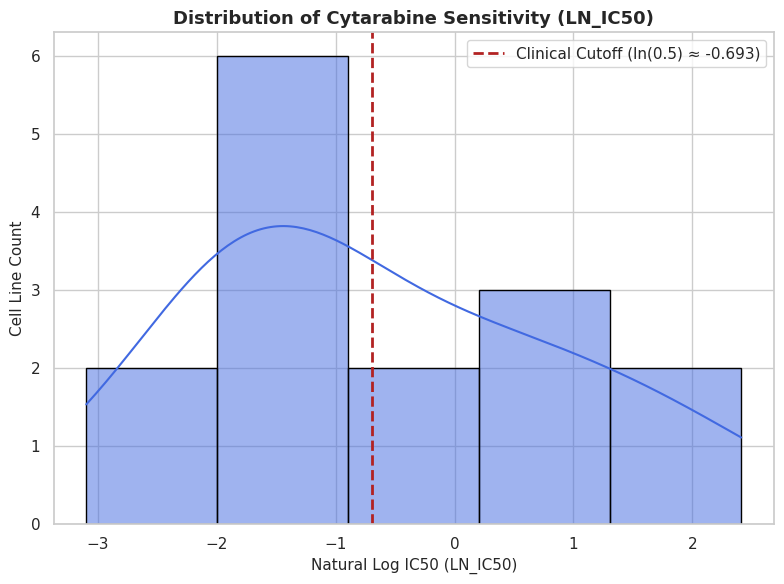

Generating Graph 2: RF Predicted vs. Actual Sensitivity...


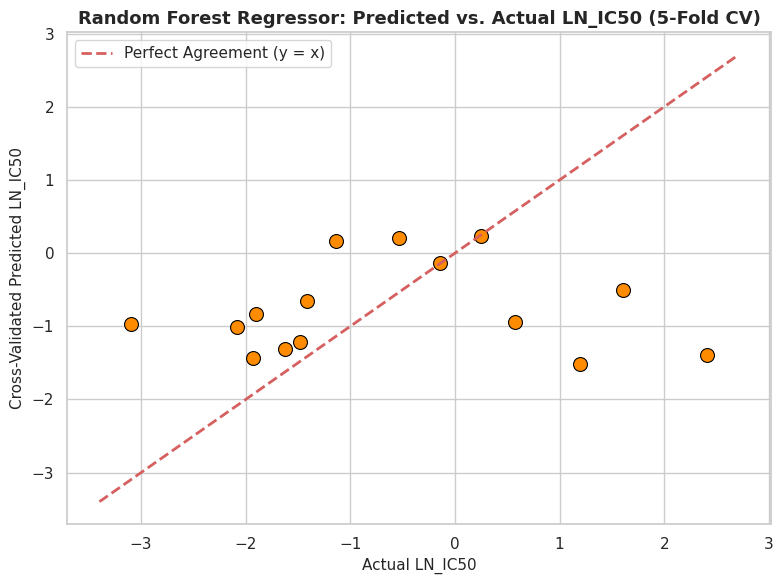

Generating Graph 3: RF Feature Importances...


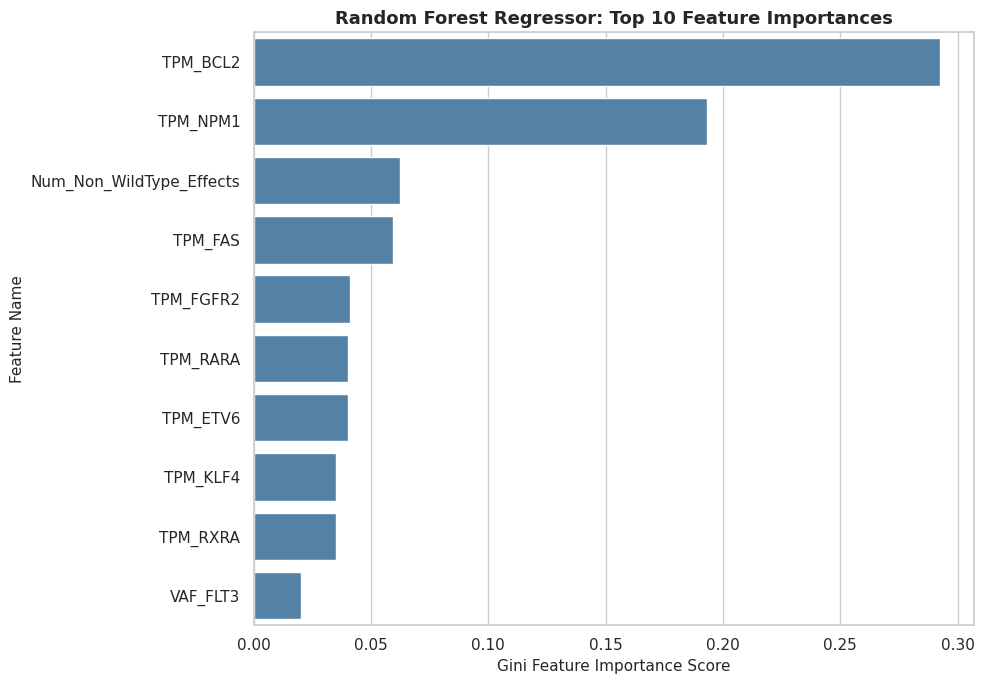

Generating Graph 4: LASSO Confusion Matrix...


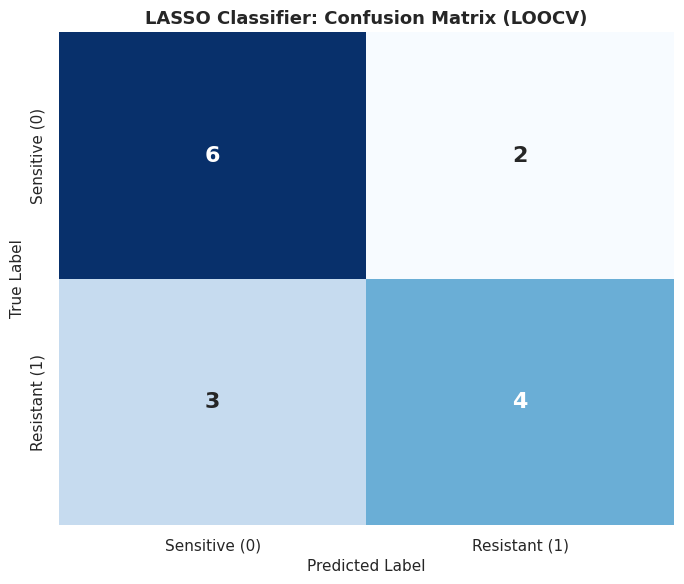

Generating Graph 5: LASSO Top 10 Coefficients...


/tmp/ipykernel_3581/3993795045.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_lasso.values, y=top_lasso.index, palette=colors)


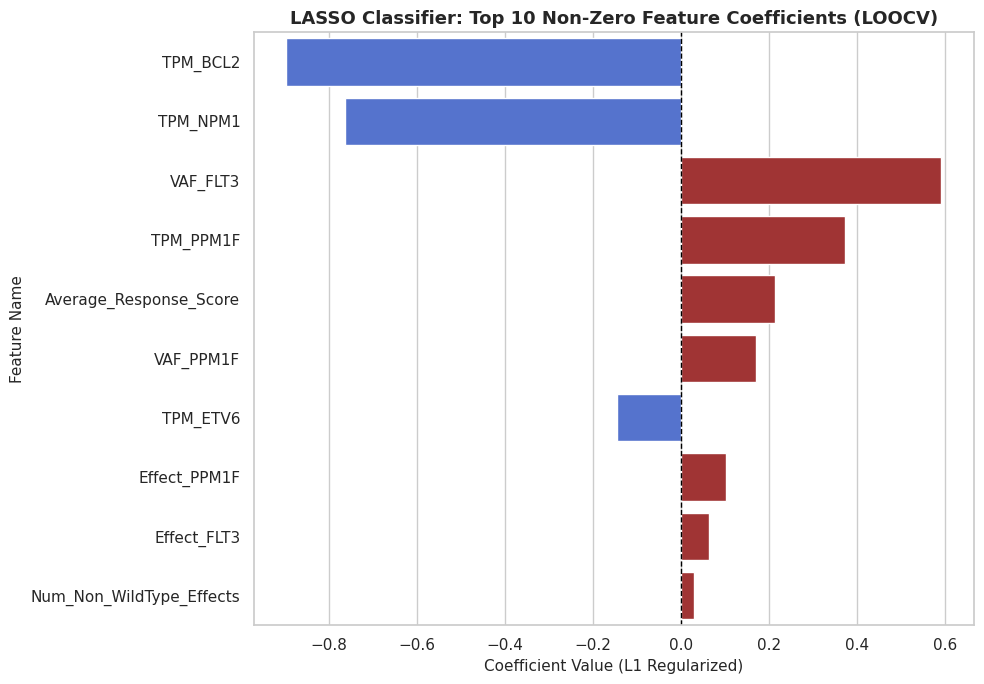


All 5 dynamic plots generated cleanly and saved to './generated_graphs/'.


In [42]:
# Set aesthetics and output directory
sns.set_theme(style="whitegrid", palette="muted")
OUTPUT_DIR = "./generated_graphs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- GRAPH 1: Distribution of LN_IC50 ---
print("Generating Graph 1: Distribution of Cytarabine Sensitivity...")
plt.figure(figsize=(8, 6))
sns.histplot(y_cont, kde=True, bins=5, color="royalblue", edgecolor="black")
plt.axvline(
    clinical_cutoff,
    color="firebrick",
    linestyle="--",
    linewidth=2,
    label=f"Clinical Cutoff (ln(0.5) ≈ {clinical_cutoff:.3f})"
)
plt.title("Distribution of Cytarabine Sensitivity (LN_IC50)", fontsize=13, weight='bold')
plt.xlabel("Natural Log IC50 (LN_IC50)", fontsize=11)
plt.ylabel("Cell Line Count", fontsize=11)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "Graph1_Sensitivity_Distribution.pdf"), format="pdf", bbox_inches="tight")
plt.close()

# --- GRAPH 2: RF Predicted vs. Actual (5-Fold CV Out-of-Fold) ---
print("Generating Graph 2: RF Predicted vs. Actual Sensitivity...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_cont, y=rf_cv_preds, s=100, color="darkorange", edgecolor="black")
min_v = min(y_cont.min(), rf_cv_preds.min()) - 0.3
max_v = max(y_cont.max(), rf_cv_preds.max()) + 0.3
plt.plot([min_v, max_v], [min_v, max_v], "r--", lw=2, label="Perfect Agreement (y = x)")
plt.title("Random Forest Regressor: Predicted vs. Actual LN_IC50 (5-Fold CV)", fontsize=13, weight='bold')
plt.xlabel("Actual LN_IC50", fontsize=11)
plt.ylabel("Cross-Validated Predicted LN_IC50", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "Graph2_RF_Predicted_vs_Actual.pdf"), format="pdf", bbox_inches="tight")
plt.close()

# --- GRAPH 3: RF Top Feature Importances ---
print("Generating Graph 3: RF Feature Importances...")
plt.figure(figsize=(10, 7))
top_rf_feats = avg_feature_importances.nlargest(10)
sns.barplot(x=top_rf_feats.values, y=top_rf_feats.index, color="steelblue")
plt.title("Random Forest Regressor: Top 10 Feature Importances", fontsize=13, weight='bold')
plt.xlabel("Gini Feature Importance Score", fontsize=11)
plt.ylabel("Feature Name", fontsize=11)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "Graph3_RF_Feature_Importances.pdf"), format="pdf", bbox_inches="tight")
plt.close()

# --- GRAPH 4: LASSO LOOCV Confusion Matrix ---
print("Generating Graph 4: LASSO Confusion Matrix...")
plt.figure(figsize=(7, 6))
cm = confusion_matrix(y_true_loo, y_pred_loo)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Sensitive (0)", "Resistant (1)"],
    yticklabels=["Sensitive (0)", "Resistant (1)"],
    annot_kws={"size": 16, "weight": "bold"}
)
plt.title("LASSO Classifier: Confusion Matrix (LOOCV)", fontsize=13, weight='bold')
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "Graph4_LASSO_Confusion_Matrix.pdf"), format="pdf", bbox_inches="tight")
plt.close()

# --- GRAPH 5: LASSO Dynamic Coefficients ---
print("Generating Graph 5: LASSO Top 10 Coefficients...")
plt.figure(figsize=(10, 7))
top_lasso = non_zero_features.reindex(non_zero_features.abs().sort_values(ascending=False).index).head(10)
colors = ["firebrick" if v > 0 else "royalblue" for v in top_lasso.values]
sns.barplot(x=top_lasso.values, y=top_lasso.index, palette=colors)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("LASSO Classifier: Top 10 Non-Zero Feature Coefficients (LOOCV)", fontsize=13, weight='bold')
plt.xlabel("Coefficient Value (L1 Regularized)", fontsize=11)
plt.ylabel("Feature Name", fontsize=11)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "Graph5_LASSO_Coefficients.pdf"), format="pdf", bbox_inches="tight")
plt.close()

print(f"\nAll 5 dynamic plots generated cleanly and saved to '{OUTPUT_DIR}/'.")

In [43]:
import os
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# Explicit local directory where Colab uploads reside
LOCAL_DIR = "/content/drive/MyDrive/TESTING DATASETS" # Corrected path to the testing datasets

print("Loading test data directly from Colab local storage...")

# 1. Verification of Local Test Files and URL for DRUG VALUES
test_cell_lines = ['ME-1', 'MOLM-13', 'OCI-AML3', 'OCI-M1']

drug_values_url = 'https://docs.google.com/spreadsheets/d/1NES3JJg3j9uDJaUCUZR4oL1A9acourk_5oyIgCxsFxc/export?format=csv&gid=0'

# Only check for local CMP files, as DRUG VALUES is now from a URL
required_local_files = [
    f"CMP_{cl}_{assay}.csv" for cl in test_cell_lines for assay in ['rnaseq', 'mutations']
]

missing = [f for f in required_local_files if not os.path.exists(os.path.join(LOCAL_DIR, f))]
if missing:
    raise FileNotFoundError(f"Missing required local file(s) in Colab local memory ({LOCAL_DIR}): {missing}")

# 2. Extract Ground Truth Response Values
# Read drug values directly from the Google Sheet URL
drug_df = pd.read_csv(drug_values_url)
drug_df.columns = drug_df.columns.astype(str).str.strip()

cl_col = [c for c in drug_df.columns if 'cell' in c.lower() or 'line' in c.lower()][0]
ln_col = [c for c in drug_df.columns if 'ln' in c.lower() or 'log' in c.lower()]

if ln_col:
    ground_truth = drug_df.set_index(cl_col)[ln_col[0]].to_dict()
else:
    ic50_col = [c for c in drug_df.columns if 'ic50' in c.lower()][0]
    ground_truth = np.log(drug_df.set_index(cl_col)[ic50_col].astype(float)).to_dict()

# 3. Model 1 Prior Setup & Mutation Dictionaries
MUTATION_EFFECT_SCORES = {
    "nonsense": 10.0, "frameshift": 9.5, "ess_splice": 9.0, "splice_variant": 9.0,
    "CNA": 9.0, "stop_lost": 8.5, "start_lost": 8.5,
    "SO:0000010:protein_coding,SO:0000147:exon,SO:0000316:CDS,SO:1000032:indel,SO:0001650:inframe_variant,SO:0001652:inframe_codon_loss": 6.0,
    "inframe": 6.0, "deletion": 6.0, "insertion": 6.0, "missense": 5.0, "snp": 5.0,
    "silent": 1.0, "wild-type": 0.0, "undefined": 0.0
}

target_genes = [
    'FLT3', 'MYC', 'ETV6', 'TRIO', 'PRDM16', 'CEBPA', 'BAX', 'KLF4',
    'PPM1F', 'RXRA', 'UGT1A10', 'BSN', 'BCL2', 'ZNF234', 'OR10J1',
    'HK3', 'NRP2', 'SEZ6L', 'ACSL1', 'ZNF777', 'PPARG', 'FAS',
    'CASP8', 'RARA', 'NPM1', 'FGFR2', 'NT5C2'
]

# Fetch literature scores from session if defined, else download reference directly
if 'gene_df' not in globals() or gene_df.empty:
    resp_url = 'https://docs.google.com/spreadsheets/d/1K23ZNh8uKkA_bYFULjkUHaFxFJQ1rMXpfUgjPQY-09o/export?format=csv&gid=0'
    ref_df = pd.read_csv(resp_url)
    resp_gene_col = [c for c in ref_df.columns if c.strip().lower() in ['gene / marker', 'gene', 'symbol']][0]
    resp_score_col = 'Response Score' if 'Response Score' in ref_df.columns else [c for c in ref_df.columns if 'score' in c.lower()][0]
    gene_df = ref_df[[resp_gene_col, resp_score_col]].copy()
    gene_df.columns = ['Gene / Marker', 'Response Score']
    gene_df['JOIN_KEY'] = gene_df['Gene / Marker'].astype(str).str.strip().str.upper()
    gene_df['Response Score'] = pd.to_numeric(gene_df['Response Score'], errors='coerce').fillna(0.0)
    gene_df = gene_df.drop_duplicates(subset=['JOIN_KEY'])

# 4. Process Local Omics Files for the 4 Test Lines
test_rows = []
for cl in test_cell_lines:
    rna_file = os.path.join(LOCAL_DIR, f"CMP_{cl}_rnaseq.csv")
    mut_file = os.path.join(LOCAL_DIR, f"CMP_{cl}_mutations.csv")

    # RNA Processing
    df_rna = pd.read_csv(rna_file)
    df_rna.columns = df_rna.columns.str.strip()
    r_sym = [c for c in ['Symbol', 'Gene', 'gene_symbol'] if c in df_rna.columns]
    r_sym = r_sym[0] if r_sym else df_rna.columns[0]
    df_rna['JOIN_KEY'] = df_rna[r_sym].astype(str).str.strip().str.upper()

    tpm_col = [c for c in df_rna.columns if 'tpm' in c.lower()][0]
    df_rna['TPM value'] = pd.to_numeric(df_rna[tpm_col].astype(str).str.replace(',', ''), errors='coerce').fillna(0.0)
    df_rna = df_rna.drop_duplicates('JOIN_KEY', keep='first')[['JOIN_KEY', 'TPM value']]

    # Mutation Processing
    df_mut = pd.read_csv(mut_file)
    df_mut.columns = df_mut.columns.str.strip()
    m_sym = [c for c in ['Symbol', 'Gene', 'gene_symbol'] if c in df_mut.columns]
    m_sym = m_sym[0] if m_sym else df_mut.columns[0]
    df_mut['JOIN_KEY'] = df_mut[m_sym].astype(str).str.strip().str.upper()

    eff_col = [c for c in df_mut.columns if 'effect' in c.lower()]
    df_mut['Effect'] = df_mut[eff_col[0]].fillna('Wild-Type').astype(str).str.strip() if eff_col else 'Wild-Type'
    df_mut['Effect_Score'] = df_mut['Effect'].str.lower().map(MUTATION_EFFECT_SCORES).fillna(0.0)

    vaf_col = [c for c in df_mut.columns if 'vaf' in c.lower()]
    df_mut['VAF'] = pd.to_numeric(df_mut[vaf_col[0]].astype(str).str.replace(',', ''), errors='coerce').fillna(0.0) if vaf_col else 0.0
    df_mut = df_mut.drop_duplicates('JOIN_KEY', keep='first')[['JOIN_KEY', 'Effect', 'Effect_Score', 'VAF']]

    # Harmonize with Model 1 literature sheet
    cl_merged = pd.merge(pd.merge(df_rna, df_mut, on='JOIN_KEY', how='outer'), gene_df, on='JOIN_KEY', how='inner')
    cl_merged['TPM value'] = cl_merged['TPM value'].fillna(0.0)
    cl_merged['Response Score'] = cl_merged['Response Score'].fillna(0.0)

    # Burden Metrics & Prior Weighting
    log_tpm = np.log2(cl_merged['TPM value'].clip(lower=0) + 1.0)
    weighted_resp = (cl_merged['Response Score'] * log_tpm).sum() / log_tpm.sum() if log_tpm.sum() > 0 else 0.0

    target_val = float(ground_truth.get(cl, np.nan))
    row = {
        'CELL LINE': cl,
        'Num_Driver_Genes': (cl_merged['Effect_Score'] >= 9.0).sum(),
        'Num_Non_WildType_Effects': (cl_merged['Effect'] != 'Wild-Type').sum(),
        'Weighted_Response_Score': weighted_resp,
        'LN_IC50': target_val
    }

    # Pivoted target gene features
    for g in target_genes:
        sub = cl_merged[cl_merged['JOIN_KEY'] == g]
        row[f"TPM_{g}"] = sub['TPM value'].values[0] if not sub.empty else 0.0
        row[f"VAF_{g}"] = sub['VAF'].values[0] if not sub.empty else 0.0

    test_rows.append(row)

test_df = pd.DataFrame(test_rows)
clinical_cutoff = np.log(0.5)
test_df['cytarabine_resistance'] = (test_df['LN_IC50'] > clinical_cutoff).astype(int)

# 5. Execute Predictions Using Existing Training Feature Space
X_train_cols = [c for c in X_df.columns if c in test_df.columns] # Changed X_clf to X_df
X_test = test_df[X_train_cols].fillna(0.0)
y_test = test_df['cytarabine_resistance']
y_test_cont = test_df['LN_IC50']

# Fit full models on all 15 discovery lines
lasso_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                penalty='l1', solver='liblinear', random_state=42, C=1.0
            ),
        ),
    ]
)
lasso_model.fit(X_df[X_train_cols], y_bin)
y_pred_lasso = lasso_model.predict(X_test)
y_prob_lasso = lasso_model.predict_proba(X_test)[:, 1]

rf_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ]
)
rf_model.fit(X_df[X_train_cols], y_cont)
y_pred_rf = rf_model.predict(X_test)

# 6. Output Final Holdout Results
results_summary = pd.DataFrame({
    'Cell Line': test_df['CELL LINE'],
    'Actual LN_IC50': y_test_cont.round(3),
    'Actual Class': test_df['cytarabine_resistance'].map({0: 'Sensitive (0)', 1: 'Resistant (1)'}),
    'LASSO Pred Prob': y_prob_lasso.round(3),
    'LASSO Prediction': pd.Series(y_pred_lasso).map({0: 'Sensitive (0)', 1: 'Resistant (1)'}),
    'RF Predicted LN_IC50': y_pred_rf.round(3),
    'Correct': (y_pred_lasso == y_test.values)
})

print("\n=== Local Blind Test Set Evaluation (N=4) ===")
display(results_summary)
print(f"Independent Test Accuracy: {accuracy_score(y_test, y_pred_lasso) * 100:.1f}%")
print(f"Random Forest Holdout RMSE: {np.sqrt(mean_squared_error(y_test_cont, y_pred_rf)):.4f}")

Loading test data directly from Colab local storage...

=== Local Blind Test Set Evaluation (N=4) ===


,Cell Line,Actual LN_IC50,Actual Class,LASSO Pred Prob,LASSO Prediction,RF Predicted LN_IC50,Correct
0,ME-1,0.420,Resistant (1),0.427,Sensitive (0),-0.648,False
1,MOLM-13,-2.239,Sensitive (0),0.682,Resistant (1),-0.580,False
2,OCI-AML3,1.652,Resistant (1),0.622,Resistant (1),0.647,True
3,OCI-M1,-2.840,Sensitive (0),0.884,Resistant (1),0.140,False


Independent Test Accuracy: 25.0%
Random Forest Holdout RMSE: 1.8559
